# H2: ZNE Baseline Comparison

Implements digital Zero-Noise Extrapolation (ZNE) for H2 and compares
against RF and unmitigated results.

ZNE method (Liao et al. Section IV.B):
- Digital gate folding on CX gates, noise factors {1, 3}
- Linear extrapolation: ZNE = (3 * val_1x - val_3x) / 2
- Runtime overhead: 2x circuits (vs 0 extra for ML-QEM)

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
import joblib
import time

from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit import transpile, QuantumCircuit

from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import Estimator as AerEstimatorV1
from qiskit_ibm_runtime.fake_provider import FakeLimaV2
from sklearn.metrics import mean_absolute_error

print('All imports OK')

All imports OK


## 1. ZNE Implementation

In [2]:
def fold_cx_gates(circuit):
    """Replace each CX with CX-CX-CX for 3x noise amplification.
    Logically equivalent (CX is self-inverse), but triples the gate noise."""
    folded = QuantumCircuit(circuit.num_qubits)
    for inst in circuit.data:
        folded.append(inst)
        if inst.operation.name == 'cx':
            folded.append(inst)
            folded.append(inst)
    return folded

print('Gate folding function ready.')

Gate folding function ready.


## 2. Load H2 Data and Setup

In [3]:
# Load data
ideal_data = np.load('ideal_data.npy')
noisy_data = np.load('noisy_data.npy')
theta_samples = np.load('theta_samples.npy')

with open('dataset_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
pauli_ops = [SparsePauliOp(p) for p in PAULI_LABELS]

# Test set: last 200 theta values
ideal_test = ideal_data[1800:]
noisy_test = noisy_data[1800:]
theta_test = theta_samples[1800:]

# Ansatz
ansatz = TwoLocal(num_qubits=2, rotation_blocks='ry',
                  entanglement_blocks='cx', entanglement='linear', reps=3)
transpiled_ansatz = transpile(ansatz, basis_gates=['rz', 'sx', 'cx', 'x'],
                              optimization_level=1)

# Noise
backend = FakeLimaV2()
noise_model = NoiseModel.from_backend(backend)
noisy_estimator = AerEstimatorV1()
noisy_estimator.set_options(noise_model=noise_model, shots=10000)

# Verify folding
test_bound = transpiled_ansatz.assign_parameters(np.zeros(8))
test_folded = fold_cx_gates(test_bound)
print(f'Original CX: {test_bound.count_ops().get("cx", 0)}')
print(f'Folded CX:   {test_folded.count_ops().get("cx", 0)} (should be 3x)')
print(f'Test set: {len(theta_test)} theta values, {len(PAULI_LABELS)} observables')

Original CX: 3
Folded CX:   9 (should be 3x)
Test set: 200 theta values, 5 observables


## 3. Run ZNE on Test Set

Reuses stored noisy values as 1x noise. Only generates 3x noise values.

Expected runtime: ~5 minutes.

In [4]:
N_TEST = len(theta_test)
N_OBS = len(pauli_ops)

noisy_3x = np.zeros((N_TEST, N_OBS))

t0 = time.time()
for i, theta in enumerate(theta_test):
    bound = transpiled_ansatz.assign_parameters(theta)
    folded = fold_cx_gates(bound)
    
    job = noisy_estimator.run([folded] * N_OBS, pauli_ops)
    res = job.result()
    
    for j in range(N_OBS):
        noisy_3x[i, j] = res.values[j]
    
    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        eta = elapsed / (i + 1) * (N_TEST - i - 1)
        print(f'  {i+1}/{N_TEST} done ({elapsed/60:.1f} min, ~{eta/60:.0f} min left)')

# Linear extrapolation
zne_vals = (3 * noisy_test - noisy_3x) / 2

print(f'Done in {(time.time()-t0)/60:.1f} min')

  50/200 done (0.4 min, ~1 min left)
  100/200 done (0.7 min, ~1 min left)
  150/200 done (1.1 min, ~0 min left)
  200/200 done (1.4 min, ~0 min left)
Done in 1.4 min


## 4. Load RF Model and Predict

In [5]:
rf = joblib.load('rf_mlqem.joblib')

# Feature construction (same as training notebook)
props = backend.properties()
N_QUBITS = 2
qubit_noise = {}
for q in range(N_QUBITS):
    qubit_noise[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q, N_SX = 3, 8

rf_corrected = noisy_test.copy()
for obs_idx in range(1, len(PAULI_LABELS)):  # skip identity
    label = PAULI_LABELS[obs_idx]
    symp = SYMPLECTIC[label]
    N = len(noisy_test)
    noise_feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        noise_feats.extend([
            qubit_noise[q]['T1'] * active,
            qubit_noise[q]['T2'] * active,
            qubit_noise[q]['readout_error'] * active,
        ])
    feats = np.column_stack([
        noisy_test[:, obs_idx], np.tile(symp, (N, 1)),
        np.full((N, 1), N_2Q), np.full((N, 1), N_SX),
        np.tile(noise_feats, (N, 1)),
    ])
    rf_corrected[:, obs_idx] = rf.predict(feats)

print('RF predictions computed.')

RF predictions computed.


## 5. Results: Per-Observable MAE

In [6]:
print(f'{"Observable":<8} {"Unmit":>8} {"ZNE":>8} {"RF":>8}')
print('-' * 36)
for j in range(1, len(PAULI_LABELS)):
    label = PAULI_LABELS[j]
    ideal_vals = ideal_test[:, j]
    mae_unm = mean_absolute_error(ideal_vals, noisy_test[:, j])
    mae_zne = mean_absolute_error(ideal_vals, zne_vals[:, j])
    mae_rf  = mean_absolute_error(ideal_vals, rf_corrected[:, j])
    print(f'{label:<8} {mae_unm:>8.4f} {mae_zne:>8.4f} {mae_rf:>8.4f}')

unmit_mae = mean_absolute_error(ideal_test[:, 1:].ravel(), noisy_test[:, 1:].ravel())
zne_mae   = mean_absolute_error(ideal_test[:, 1:].ravel(), zne_vals[:, 1:].ravel())
rf_mae    = mean_absolute_error(ideal_test[:, 1:].ravel(), rf_corrected[:, 1:].ravel())

print(f'\nOverall MAE:')
print(f'  Unmitigated: {unmit_mae:.4f}')
print(f'  ZNE:         {zne_mae:.4f}  ({unmit_mae/zne_mae:.1f}x improvement)')
print(f'  RF:          {rf_mae:.4f}  ({unmit_mae/rf_mae:.1f}x improvement)')
print(f'\n  RF vs ZNE:   {"RF wins" if rf_mae < zne_mae else "ZNE wins"}')

Observable    Unmit      ZNE       RF
------------------------------------
IZ         0.0261   0.0272   0.0084
ZI         0.0220   0.0237   0.0085
ZZ         0.0469   0.0477   0.0077
XX         0.0446   0.0451   0.0089

Overall MAE:
  Unmitigated: 0.0349
  ZNE:         0.0359  (1.0x improvement)
  RF:          0.0084  (4.2x improvement)

  RF vs ZNE:   RF wins


## 6. Energy MAE

In [7]:
coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_test @ coeffs
E_unm   = noisy_test @ coeffs
E_zne   = zne_vals @ coeffs

rf_corr = rf_corrected.copy()
rf_corr[:, 0] = 1.0
E_rf = rf_corr @ coeffs

print(f'H2 Energy MAE (Ha):')
print(f'  Unmitigated: {mean_absolute_error(E_ideal, E_unm):.5f}')
print(f'  ZNE:         {mean_absolute_error(E_ideal, E_zne):.5f}')
print(f'  RF:          {mean_absolute_error(E_ideal, E_rf):.5f}')
print(f'  Chem. acc.:  0.00160')

H2 Energy MAE (Ha):
  Unmitigated: 0.01555
  ZNE:         0.01603
  RF:          0.00461
  Chem. acc.:  0.00160


## 7. Plot

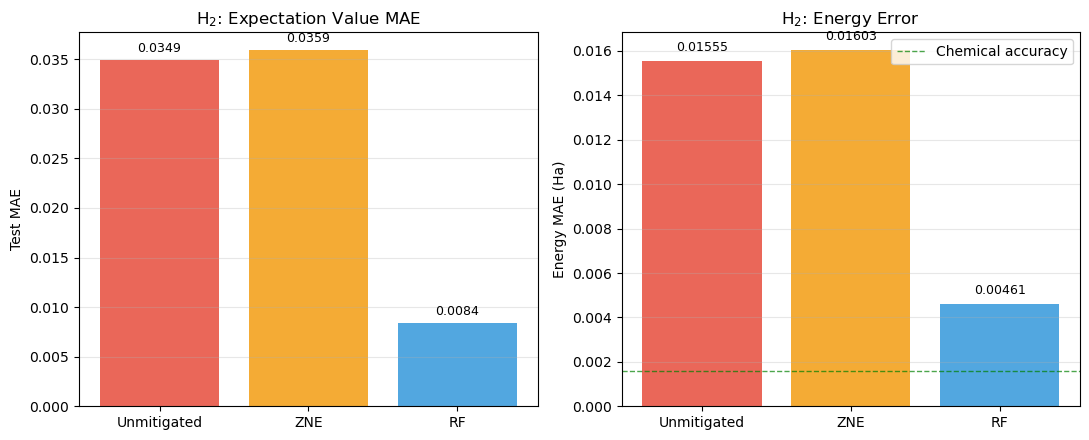

Saved: h2_zne_comparison.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: observable MAE
ax = axes[0]
methods = ['Unmitigated', 'ZNE', 'RF']
maes = [unmit_mae, zne_mae, rf_mae]
colors = ['#e74c3c', '#f39c12', '#3498db']
bars = ax.bar(methods, maes, color=colors, alpha=0.85)
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Test MAE')
ax.set_title('H$_2$: Expectation Value MAE')
ax.grid(axis='y', alpha=0.3)

# Right: energy MAE
ax = axes[1]
e_maes = [mean_absolute_error(E_ideal, E_unm),
          mean_absolute_error(E_ideal, E_zne),
          mean_absolute_error(E_ideal, E_rf)]
bars = ax.bar(methods, e_maes, color=colors, alpha=0.85)
for bar, val in zip(bars, e_maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
            f'{val:.5f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.0016, color='green', linestyle='--', linewidth=1,
           label='Chemical accuracy', alpha=0.7)
ax.set_ylabel('Energy MAE (Ha)')
ax.set_title('H$_2$: Energy Error')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('h2_zne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: h2_zne_comparison.png')